# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** [seif mohamed sayed hashem]  
**Student ID:** [1210102]

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [13]:
# Load dataset
df = pd.read_csv("kidney_disease.csv")

# Clean and convert target column
df["classification"] = df["classification"].str.strip()
df["classification"] = df["classification"].map({"ckd": 1, "notckd": 0})

# Separate target
y = df["classification"]

# Keep only numeric feature columns
X = df.select_dtypes(include=[np.number]).drop("classification", axis=1)

# Handle missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

# Train/Validation split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (NO data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Unique labels:", y.unique())

Train shape: (320, 12)
Validation shape: (80, 12)
Unique labels: [1 0]


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


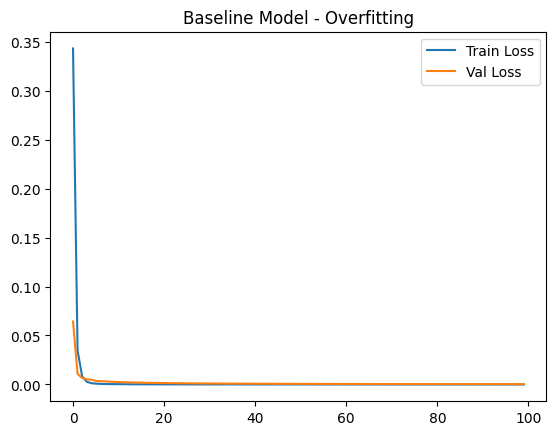

In [14]:
model1 = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history1 = model1.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=0
)

# Plot loss curves
plt.figure()
plt.plot(history1.history["loss"], label="Train Loss")
plt.plot(history1.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Baseline Model - Overfitting")
plt.show()

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

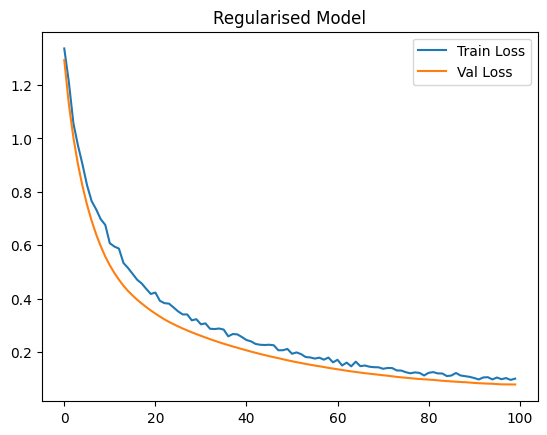

In [15]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.01),
        input_shape=(X_train.shape[1],)
    ),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(
        16,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.01)
    ),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.Recall()]
)

history2 = model2.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=0
)

# Plot loss curves
plt.figure()
plt.plot(history2.history["loss"], label="Train Loss")
plt.plot(history2.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Regularised Model")
plt.show()

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

In [16]:

# Baseline predictions
y_pred1 = (model1.predict(X_val) > 0.5).astype(int)

print("Baseline Confusion Matrix:")
print(confusion_matrix(y_val, y_pred1))
print("Baseline Recall:", recall_score(y_val, y_pred1))


# Engineered predictions
y_pred2 = (model2.predict(X_val) > 0.5).astype(int)

print("\nEngineered Confusion Matrix:")
print(confusion_matrix(y_val, y_pred2))
print("Engineered Recall:", recall_score(y_val, y_pred2))

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Baseline Confusion Matrix:
[[28  0]
 [ 0 52]]
Baseline Recall: 1.0
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Engineered Confusion Matrix:
[[28  0]
 [ 0 52]]
Engineered Recall: 1.0


In [17]:
model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,885 (11.27 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,924 (7.52 KB)

### Mathematical Justification
**Final Parameter Count of Engineered Model:** [2885]

**Explanation:** [
ith only 400 patients, limiting the model to 2,885 parameters and applying L2 regularisation and dropout constrains the hypothesis space, reduces variance, and mathematically prevents memorisation by penalising large weights and randomly deactivating neurons during training..]